Epoch 1 Loss = 0.5972 Accuracy = 69.4%
Epoch 21 Loss = 0.3457 Accuracy = 90.9%
Epoch 41 Loss = 0.2777 Accuracy = 92.6%
Epoch 61 Loss = 0.2363 Accuracy = 93.9%
Epoch 81 Loss = 0.2066 Accuracy = 93.9%


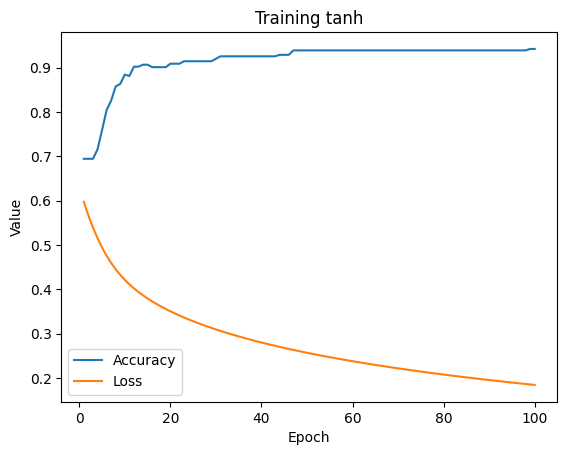

Accuracy  : 0.9600
Precision : 0.9375
Recall    : 0.9375
F1 Score  : 0.9375


In [25]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(linewidth=5000, precision=2)
# Sigmoid output

# W = (neurons, features)
# X = (features, samples)

def act(Z, t):
    if t == 'relu': return np.maximum(0, Z)
    if t == 'sigmoid': return 1 / (1 + np.exp(-Z))
    if t == 'tanh': return np.tanh(Z)

def act_d(A, t):
    if t == 'relu': return (A > 0).astype(float)
    if t == 'sigmoid': return A * (1 - A)
    if t == 'tanh': return 1 - A**2

def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return expZ / np.sum(expZ, axis=0, keepdims=True)



def init(layers):
    n,h1,h2,c = layers
    W1 = np.random.randn(h1, n) * np.sqrt(2/n)
    b1 = np.zeros((h1,1))
    W2 = np.random.randn(h2,h1) * np.sqrt(2/h1)
    b2 = np.zeros((h2,1))
    W3 = np.random.randn(c,h2) * np.sqrt(2/h2)
    b3 = np.zeros((c,1))
    return [W1,b1,W2,b2,W3,b3]



def forward(X, params, act1, act2):
    W1,b1,W2,b2,W3,b3 = params

    Z1 = W1 @ X + b1
    A1 = act(Z1, act1)
    Z2 = W2 @ A1 + b2
    A2 = act(Z2, act2)
    Z3 = W3 @ A2 + b3
    A3 = act(Z3,"sigmoid")
    return A3, (A1,A2,A3)



def compute_loss(y,y_pred):
    y = y.reshape(1,-1)
    m = y.shape[1]
    return -np.sum(y * np.log(y_pred + 1e-8)+(1-y) * np.log((1-y_pred) + 1e-8)) / m



def backward(X, y, params, cache, act1, act2):
    W1,b1,W2,b2,W3,b3 = params
    A1,A2,A3 = cache

    m = X.shape[1]
    y = y.reshape(1, -1)

    dZ3 = A3 - y
    dW3 = dZ3 @ A2.T / m
    db3 = np.sum(dZ3, axis=1, keepdims=True) / m

    dZ2 = (W3.T @ dZ3) * act_d(A2, act2)
    dW2 = dZ2 @ A1.T / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m

    dZ1 = (W2.T @ dZ2) * act_d(A1, act1)
    dW1 = dZ1 @ X.T / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m

    return [dW1,db1,dW2,db2,dW3,db3]



def update(params, grads, lr):
    W1,b1,W2,b2,W3,b3 = params
    dW1,db1,dW2,db2,dW3,db3 = grads

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
    W3 -= lr * dW3
    b3 -= lr * db3
    return [W1,b1,W2,b2,W3,b3]



def train(X, y,layers, epochs=50, lr=0.1, act1='relu', act2='relu'):
    params = init(layers)
    loss = []
    acc = []

    for i in range(epochs):
        y_pred, cache = forward(X, params, act1, act2)
        l = compute_loss(y,y_pred)
        grads = backward(X, y, params, cache, act1, act2)
        params = update(params, grads, lr)

        a = accuracy(y,y_pred)
        acc.append(a)
        loss.append(l)

        if i%20==0:
          print(f"Epoch {i+1} Loss = {l:.4f} Accuracy = {a*100:0.1f}%")

    return params,loss,acc



def accuracy(y,y_pred):
  preds = (y_pred > 0.5).astype(int).flatten()
  return np.mean(y == preds)





def evaluate(X, y, params, act1, act2):
    y_pred, _ = forward(X, params, act1, act2)
    preds = (y_pred > 0.5).astype(int).flatten()
    return preds



def metrics(y_true, y_pred):
    y_pred = (y_pred > 0.5).astype(int).flatten()
    accuracy = np.mean(y_true == y_pred)

    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = (2 * precision * recall)/ (precision + recall + 1e-8)

    return accuracy, precision, recall, f1



def plot_metrics(loss, acc, title="Training"):
      epochs = range(1, len(loss)+1)

      plt.plot(epochs, acc, label='Accuracy')
      plt.plot(epochs, loss, label='Loss')

      plt.title(title)
      plt.xlabel("Epoch")
      plt.ylabel("Value")

      plt.legend()
      plt.show()




# ---------Data------------------------------------------
np.random.seed(0)
samples = 1000

# Features
age = np.random.randint(15, 23, samples)
height = np.random.randint(150, 170, samples)

# X shape = (2, 1000)
X = np.array([age, height])
X = (X - np.mean(X, axis=1, keepdims=True)) / np.std(X, axis=1, keepdims=True)
y = ((age >= 18) & (height >= 160)).astype(int)

X_train = X[:, 0:900]
y_train = y[0:900]

X_test = X[:, 900:1000]
y_test = y[900:1000]

#------------------------
params, loss, acc = train(
    X_train,
    y_train,
    layers=(2,8,4,1),
    epochs=100,
    lr=0.1,
    act1='tanh',
    act2='tanh'
    )

plot_metrics(loss, acc, "Training tanh")


# Testing

y_pred, _ = forward(
    X_test,
    params,
    'tanh',
    'tanh'
)

acc, prec, rec, f1 = metrics(y_test, y_pred)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
